In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
import pennylane as qml

from pennylane import numpy as np
from pennylane.math import requires_grad

## Constantes

In [45]:
dataset = 'fraud'
ntrain = 0 ; latent_dim = 3
num_params_conv = 45
cost_func = 'svdd'
steps = 300
learning_rate = 0.001
batch_size = 16

## Dataset

In [46]:
print("Diretório atual:", os.getcwd())
print("Arquivos nesta pasta:", os.listdir())

Diretório atual: /home/jvfg/Documents/Pesquisa/QSVDD2/notebooks/original_qcnn_experiments
Arquivos nesta pasta: ['qcnn_embedding_exploration.ipynb', 'qcnn_unbalanced_exploration.ipynb', 'qcnn_different_layers_exploration.ipynb', 'qcnn_normalization_exploration.ipynb']


## Explorando Dataset Desbalanceado

In [47]:
file_path = os.path.join("../..", "data", "creditcard.csv")
df = pd.read_csv(file_path)

print("Dataset carregado com sucesso!\n")
print("First 5 records:\n", df.head())

Dataset carregado com sucesso!

First 5 records:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141

In [48]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [49]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


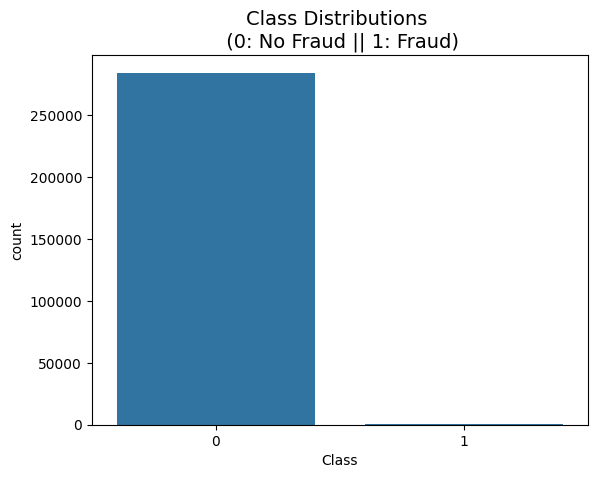

In [50]:
plt.style.use('default')

sns.countplot(x='Class', data=df)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

plt.show()

In [51]:
# separa os valores das transações financeiras (coluna Amount) de acordo com a categoria da transação (coluna Class).
tmp = df[['Amount','Class']].copy()
class_0 = tmp.loc[tmp['Class'] == 0]['Amount']
class_1 = tmp.loc[tmp['Class'] == 1]['Amount']

In [52]:
class_0.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [53]:
class_1.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [54]:
# separa o rótulo do dataset e o armazenando em x o dataset sem rótulo e em y o rótulo
X = df.drop("Class", axis=1)
y = df['Class']

In [55]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X

array([[0.00000000e+00, 9.35192337e-01, 7.66490419e-01, ...,
        4.18976135e-01, 3.12696634e-01, 5.82379309e-03],
       [0.00000000e+00, 9.78541955e-01, 7.70066651e-01, ...,
        4.16345145e-01, 3.13422663e-01, 1.04705276e-04],
       [5.78730497e-06, 9.35217023e-01, 7.53117667e-01, ...,
        4.15489266e-01, 3.11911316e-01, 1.47389219e-02],
       ...,
       [9.99976851e-01, 9.90904812e-01, 7.64079694e-01, ...,
        4.16593177e-01, 3.12584864e-01, 2.64215395e-03],
       [9.99976851e-01, 9.54208999e-01, 7.72855742e-01, ...,
        4.18519535e-01, 3.15245157e-01, 3.89238944e-04],
       [1.00000000e+00, 9.49231759e-01, 7.65256401e-01, ...,
        4.16466371e-01, 3.13400843e-01, 8.44648509e-03]],
      shape=(284807, 30))

In [56]:
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

print('y value counts:')
print(y.value_counts())

X shape: (284807, 30)
y shape: (284807,)
y value counts:
Class
0    284315
1       492
Name: count, dtype: int64


In [57]:
"""
One-class Training:
Separação em exemplos normais e fraudulentos
O QSVDD irá aprender o que é normal.
"""
normal_indices = y[y == 0].index
abnormal_indices = y[y == 1].index


# Treino
# coleta 1000 exemplos normais para o treino
X_train_normal_indices = np.random.choice(normal_indices, 1000, replace=False)
X_train_normal = X[X_train_normal_indices]
y_train_normal = y[X_train_normal_indices]

# X_train contém apenas transações legítimas
X_train = X_train_normal
Y_train = y_train_normal

# Teste (balanceado)
# O código retira 100 exemplos normais que não foram usados no treino
remaining_normal_indices = list(set(normal_indices) - set(X_train_normal_indices))
X_test_normal_indices = np.random.choice(remaining_normal_indices, 100, replace=False)
X_test_normal = X[X_test_normal_indices]
y_test_normal = y[X_test_normal_indices]

# O código retira 100 exemplos de fraudes.
X_test_abnormal_indices = np.random.choice(abnormal_indices, 100, replace=False)
X_test_abnormal = X[X_test_abnormal_indices]
y_test_abnormal = y[X_test_abnormal_indices]

# cria um conjunto de teste com 200 exemplos (50% normal, 50% fraude)
X_test = np.concatenate((X_test_normal, X_test_abnormal), axis=0)
Y_test = np.concatenate((y_test_normal, y_test_abnormal), axis=0)

# define o centro da hiperesfera no espaço latente quântico.
"""
É o ponto para onde o modelo tentará "empurrar" todos os dados normais.
No QSVDD, o objetivo é minimizar a distância entre a saída do circuito quântico
e este centro.
"""
center = qml.numpy.zeros(latent_dim, requires_grad=True)
center_train = np.tile(center,(len(X_train),1)) # conveniência para calcular o loss

print(f'X_train shape: {X_train.shape}')
print(f'Y_train shape: {Y_train.shape}')
print(f'X_test_normal shape: {X_test_normal.shape}')
print(f'X_test_abnormal shape: {X_test_abnormal.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Y_test shape: {Y_test.shape}')
print(f'center_train shape: {center_train.shape}')

X_train shape: (1000, 30)
Y_train shape: (1000,)
X_test_normal shape: (100, 30)
X_test_abnormal shape: (100, 30)
X_test shape: (200, 30)
Y_test shape: (200,)
center_train shape: (1000, 3)


## Treinamento

In [58]:
def qae_loss(Y, predictions):
    loss = 0
    for l, p in zip(Y, predictions):
        loss = loss + (-np.sum(p))
    loss = loss / len(Y)
    return loss

def svdd_loss(Y, predictions):
    loss = 0
    for l, p in zip(Y, predictions):
        loss = loss + np.sum(np.array(p-l)**2)
    loss = loss / len(Y)
    return loss


def cost(params, X, Y, U_params, latent_dim, cost_fn):
    predictions = np.array([QCNN(x, params, U_params, latent_dim, cost_fn) for x in X])
    if cost_fn == 'qae':
        loss_value = qae_loss(Y, predictions)

    elif cost_fn == 'svdd':
        loss_value = np.square(np.subtract(predictions, Y)).mean()

    return loss_value
def circuit_training(X_train, Y_train, U_params, cost_fn, latent_dim):
    if cost_fn == 'qae':
        params = np.random.randn(78, requires_grad = True)

    elif cost_fn == 'svdd':
        # inicia os parâmetros aleatoriamente (normal dist- mean=0 e var=1)
        # requires_grad = True coloca uma etiqueta nos parâmetros indicando que o gradiente deve ser tomado.
        params = np.random.randn(U_params * 5, requires_grad = True)
    opt = qml.AdamOptimizer(stepsize=learning_rate)
    param_history= [params]
    loss_history = []

    for it in range(steps):

        batch_index = np.random.randint(0, len(X_train), (batch_size,))
        X_batch = np.array([X_train[i] for i in batch_index])
        Y_batch = np.array([Y_train[i] for i in batch_index])

        params, cost_new = opt.step_and_cost(lambda v: cost(v, X_batch, Y_batch, U_params, latent_dim, cost_fn), params)
        param_history.append(params)
        loss_history.append(cost_new)


        print("iteration: ", it, " cost: ", cost_new)


    return loss_history, params, param_history

## Componentes do Circuito Quântico

In [59]:
# Unitary

def U_SU4(params, wires): # 15 params
    qml.U3(params[0], params[1], params[2], wires=wires[0])
    qml.U3(params[3], params[4], params[5], wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])
    qml.RY(params[6], wires=wires[0])
    qml.RZ(params[7], wires=wires[1])
    qml.CNOT(wires=[wires[1], wires[0]])
    qml.RY(params[8], wires=wires[0])
    qml.CNOT(wires=[wires[0], wires[1]])
    qml.U3(params[9], params[10], params[11], wires=wires[0])
    qml.U3(params[12], params[13], params[14], wires=wires[1])

# Convolution layer

def conv_layer_1(U, params):
    U(params, wires=[0,1])
    U(params, wires=[2,3])
    U(params, wires=[4,0])
    U(params, wires=[1,2])
    U(params, wires=[3,4])

def conv_layer_2(U, params):
    U(params, wires=[0,1])
    U(params, wires=[2,3])
    U(params, wires=[0,3])
    U(params, wires=[1,2])

def conv_layer_3(U, params):
    U(params, wires=[0,1])

def QCNN_structure_without_pooling(U, params, U_params): #75
    param1 = params[0:U_params]
    param2 = params[U_params: 2 * U_params]
    param3 = params[2 * U_params: 3 * U_params]
    param4 = params[3 * U_params: 4 * U_params]
    param5 = params[4 * U_params: 5 * U_params]

    conv_layer_1(U, param1)
    conv_layer_1(U, param2)
    conv_layer_2(U, param3)
    conv_layer_2(U, param4)
    conv_layer_3(U, param5)

`qml.Pauli#(0) @ qml.Pauli#(1)` extrai o que chamamos de Informação Completa de Correlação.
1. $X \times X$: Mede correlações de fase.
2. $Y \times Y$: Mede correlações complexas.
3. $Z \times Z$: Mede correlações de amplitude (se ambos são $|0\rangle$ ou $|1\rangle$ ao mesmo tempo).

In [60]:
# QCNN

dev = qml.device('default.qubit', wires = 5)
@qml.qnode(dev, interface = 'autograd', diff_method = 'backprop')
def QCNN(X, params, U_params, latent_dim, cost_fn='svdd'):

    # AmplitudeEmbedding pega o vetor clássico e o converte em estado quantico
    qml.AmplitudeEmbedding(X, wires=range(5), pad_with=0., normalize=True)
    QCNN_structure_without_pooling(U_SU4, params, U_params)

    result = qml.expval(qml.PauliX(0) @ qml.PauliX(1)), qml.expval(qml.PauliY(0) @ qml.PauliY(1)), qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

    return result

train_Xdata = X_train
train_Ydata = center_train


loss_history, est_params, param_history = circuit_training(X_train=train_Xdata,
                                            Y_train=train_Ydata,
                                            U_params=num_params_conv,
                                            latent_dim = latent_dim,
                                            cost_fn=cost_func)

iteration:  299  cost:  0.0003321235733765762


## Plots

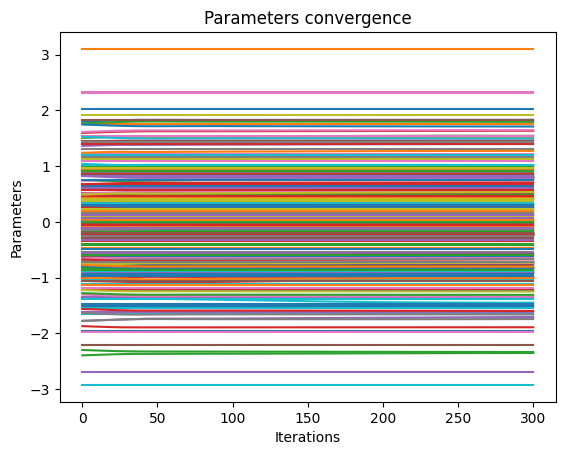

In [61]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")


plt.style.use('default')
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss convergence")
plt.show()

plt.plot(param_history)
plt.xlabel("Iterations")
plt.ylabel("Parameters")
plt.title("Parameters convergence")
plt.show()

## Teste

In [62]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

def radius(data, center):
    res = []

    res.append(abs(data - center)**2)
    return res

In [63]:
import time
import numpy as np
import random
from sklearn.metrics import roc_curve, roc_auc_score

trained_params = est_params
y_true = []
y_pred = []

def test(ntrain, latent_dim):
    start_time = time.time()
    print(f"Starting test function with ntrain={ntrain}, latent_dim={latent_dim}")

    for i in range(2):
        step_start_time = time.time()
        if i == ntrain:
            print(f"Processing class {ntrain} for latent_dim>1 with cost_func=svdd")
            filter = np.where(Y_test == ntrain)
            test_data = X_test[filter]

            pred = np.asarray([QCNN(x, trained_params, U_params=num_params_conv,
                                    latent_dim=latent_dim, cost_fn=cost_func) for x in test_data])
            for j in range(len(pred)):
                y_pred.append((pred**2).mean(axis=1)[j])
                y_true.append(0)
        else:
            print(f"Processing class {i} for latent_dim>1 with cost_func=svdd")
            filter = np.where(Y_test == i)
            test_data = X_test[filter]

            pred = np.asarray([QCNN(x, trained_params, U_params=num_params_conv,
                                    latent_dim=latent_dim, cost_fn=cost_func) for x in test_data])
            for j in range(len(pred)):
                y_pred.append((pred**2).mean(axis=1)[j])
                y_true.append(1)
        step_end_time = time.time()
        print(f"Finished processing class {i} in {step_end_time - step_start_time:.2f} seconds")


    print("Calculating ROC curve and AUC score")
    roc_start_time = time.time()
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    roc_end_time = time.time()
    print(f"Calculated ROC and AUC in {roc_end_time - roc_start_time:.2f} seconds")

    end_time = time.time()
    print(f"Finished test function with AUC={auc} in {end_time - start_time:.2f} seconds")

    return auc, y_pred, y_true, fpr, tpr

auc, y_pred, y_true, fpr, tpr = test(ntrain, latent_dim)
print("Test completed")

Finished processing class 1 in 3.96 seconds
Calculating ROC curve and AUC score
Calculated ROC and AUC in 0.00 seconds
Finished test function with AUC=0.9375000000000001 in 8.04 seconds
Test completed


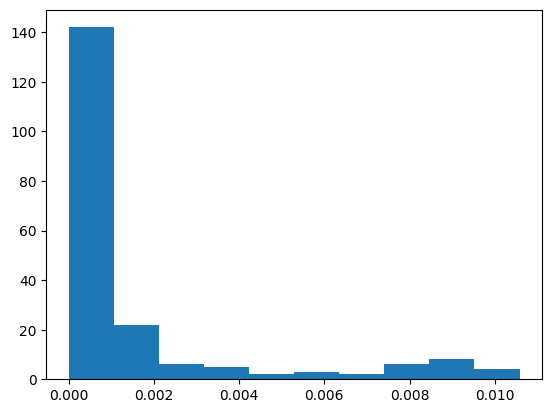

In [64]:
plt.hist(y_pred)

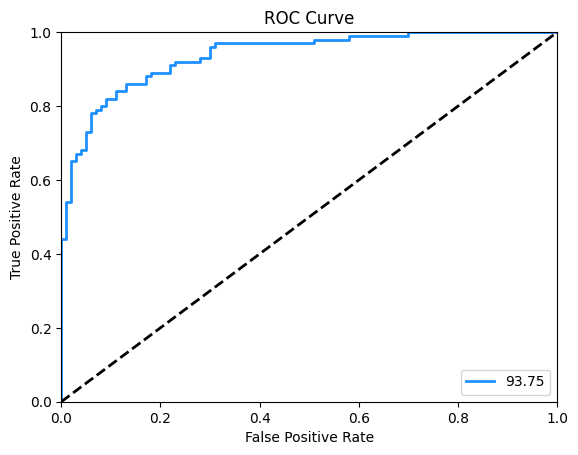

In [65]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import os


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='dodgerblue', lw=lw, label="{:.2f}".format(auc * 100))
plt.plot([0, 1], [0, 1], color="black", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

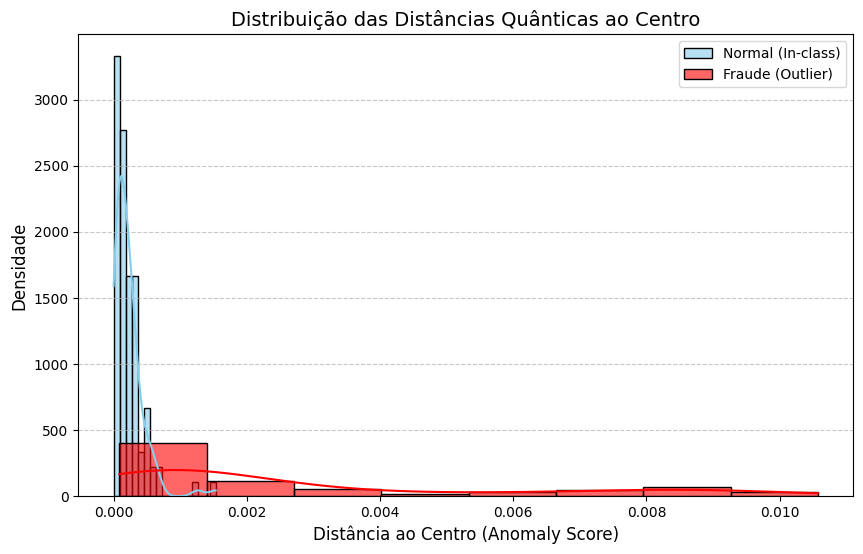

In [66]:
import seaborn as sns

def plot_distances(y_true, y_pred):
    # Convertendo para arrays caso não sejam
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Separando as distâncias por classe
    dist_normais = y_pred[y_true == 0]
    dist_fraudes = y_pred[y_true == 1]

    plt.figure(figsize=(10, 6))

    # Plotando as distribuições
    # A densidade representa a concentração de probabilidade.
    # Em termos simples, ela indica o quão comum é encontrar uma transação naquela distância específica.
    sns.histplot(dist_normais, color="skyblue", label="Normal (In-class)", kde=True, stat="density", alpha=0.6)
    sns.histplot(dist_fraudes, color="red", label="Fraude (Outlier)", kde=True, stat="density", alpha=0.6)

    # Adicionando detalhes ao gráfico
    plt.title("Distribuição das Distâncias Quânticas ao Centro", fontsize=14)
    plt.xlabel("Distância ao Centro (Anomaly Score)", fontsize=12)
    plt.ylabel("Densidade", fontsize=12)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

# Chame a função após rodar o seu teste
plot_distances(y_true, y_pred)

In [67]:
from itertools import combinations

def U_QAE(params): # params: 14
    nqubits = 5
    ntrash = 3
    for i in range(nqubits):
        qml.RY(params[i], wires = i)

    for i,j in combinations(range(0, ntrash), 2): # CZ between trash qubits
        qml.CZ(wires = [i, j])

    for idx in range(ntrash): # CZ between trash and non-trash qubits
        for i in range(ntrash):
            for j in range(ntrash+i,nqubits,ntrash):
                qml.CZ(wires = [(idx+i)%(ntrash),j])

def U_QAE_last(params):
    ntrash = 3
    for i in range(ntrash):
        qml.RY(params[i], wires = i)

def QSVDD_QAE(U, params, U_params):
    param1 = params[0:U_params]
    param2 = params[U_params: 2 * U_params]
    param3 = params[2 * U_params: 3 * U_params]
    param4 = params[3 * U_params: 4 * U_params]
    param5 = params[4 * U_params: 5 * U_params]
    param6 = params[5 * U_params: 6 * U_params]
    param7 = params[6 * U_params: 7 * U_params]
    param8 = params[7 * U_params: 8 * U_params]
    param9 = params[8 * U_params: 9 * U_params]
    param10 = params[9 * U_params: 78]

    U_QAE(param1)
    U_QAE(param2)
    U_QAE(param3)
    U_QAE(param4)
    U_QAE(param5)
    U_QAE(param6)
    U_QAE(param7)
    U_QAE(param8)
    U_QAE(param9)
    U_QAE_last(param10)